# Naive Bayes

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB # use to create NB model
from sklearn.metrics import f1_score # use to compute F1 score
from sklearn.model_selection import cross_val_score # use to perform cross-validation
import matplotlib.pyplot as plt # use to plot

In [2]:
# Load data
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
vectorizer = TfidfVectorizer() # create TF-IDF vectorizer to convert text to numerical features
X_train = vectorizer.fit_transform(train_data['Article']) # learn vocabulary from training data and assign weight for each word
X_test = vectorizer.transform(test_data['Article']) # transform test data into same feature space as training data
y_train = train_data['Category']
y_test = test_data['Category']
feature_names = vectorizer.get_feature_names_out() # get feature names (words) from vectorizer

In [10]:
nb = MultinomialNB() # create NB model
nb.fit(X_train, y_train)

classes = nb.classes_  # get class labels
log_probs = nb.feature_log_prob_ # log_probs[i][j] = log P(word_j | class_i)

# (i) Top 20 most predictive words for each class
for i, label in enumerate(classes):
    top20 = log_probs[i].argsort()[::-1][:20]
    words = [feature_names[j] for j in top20]
    probs = [np.exp(log_probs[i][j]) for j in top20]
    df = pd.DataFrame({'word': words, 'P(word|class)': probs})
    print(label)
    display(df)

entertainment


,word,P(word|class)
0,film,0.000782
1,best,0.000637
2,said,0.000498
3,show,0.000401
4,band,0.000394
5,music,0.000389
6,year,0.000379
7,awards,0.000377
8,us,0.000362
9,award,0.000347


tech


,word,P(word|class)
0,said,0.000697
1,people,0.000578
2,mobile,0.000563
3,software,0.000429
4,games,0.000426
5,phone,0.000419
6,net,0.000413
7,users,0.000391
8,technology,0.000388
9,mr,0.000387


In [14]:
# (ii) Most discriminative words between 'tech' and 'entertainment'
tech_index = list(classes).index('tech')
entertainment_index = list(classes).index('entertainment')

log_ratio = log_probs[tech_index] - log_probs[entertainment_index]
top20_discriminative = log_ratio.argsort()[::-1][:20] # get index of top 20 words with highest log ratio

df_discriminative = pd.DataFrame({'word': [feature_names[j] for j in top20_discriminative], 'P(word|tech)/P(word|entertainment)': [np.exp(log_ratio[j]) for j in top20_discriminative]})
df_discriminative


,word,P(word|tech)/P(word|entertainment)
0,mobile,8.379342
1,software,6.675569
2,users,6.091572
3,microsoft,6.009524
4,games,5.986544
5,net,5.947777
6,technology,5.775116
7,virus,5.675334
8,phone,5.641710
9,broadband,5.603785


**Which list of words describe the two classes better**

The 20 most discriminative words between the classes is better. I just compare the probability of each word appearing in the "tech" class with its probability of appearing in the "entertainment" class. I find in top 20 most predictive words, most words are common word or don't have strong relationship with that class like "best, said, new, could and etc.", but in top20_discriminative word (mobile, software, users and etc.) are more relate to the class. So the 20 most discriminative words are more useful to separate two classes.

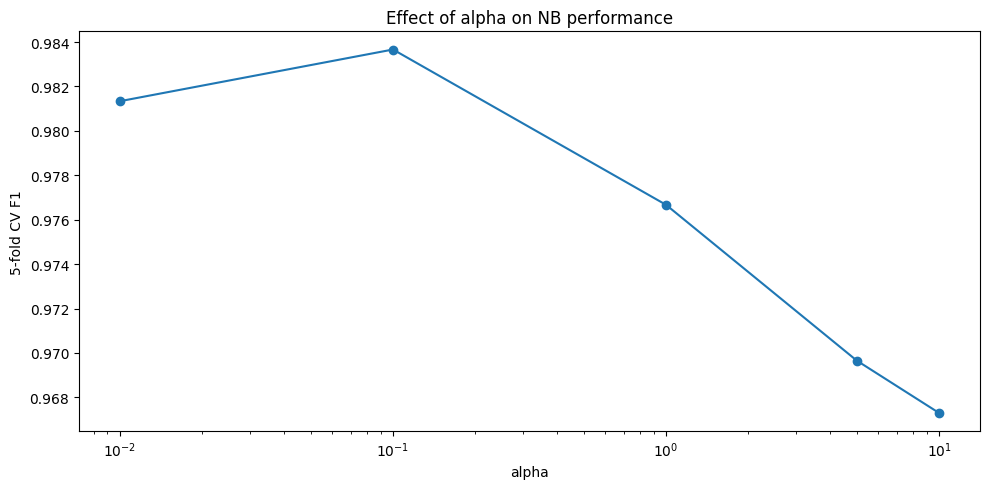

Best alpha: 0.1 (CV F1: 0.9837)


In [5]:
# Task 3(a): Hyperparameter investigation
alphas = [0.01, 0.1, 1.0, 5.0, 10.0]
cross_validation_scores = []
for alpha in alphas:
    nb_alpha = MultinomialNB(alpha=alpha)
    cv_score = cross_val_score(nb_alpha, X_train, y_train, cv=5, scoring='f1_macro').mean() # compute mean F1 score across 5 folds
    cross_validation_scores.append(cv_score)

plt.figure(figsize=(10, 5))
plt.plot(alphas, cross_validation_scores, marker='o')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('5-fold CV F1')
plt.title('Effect of alpha on NB performance')
plt.tight_layout(); plt.show()

best_alpha = alphas[np.argmax(cross_validation_scores)]
print(f'Best alpha: {best_alpha} (CV F1: {max(cross_validation_scores):.4f})')

For task 3(a), I investigate the affect of alpha hyperparaeter in NB, I choose(0.01, 0.1, 1.0, 5.0, 10.0) using 5 fold cross-validation and F1 to evaluate training set. From the plot, we can see that when alpha is 0.1, F1 score is highest it's 0.9837. So I choose alpha = 0.1 to be the best hyperparameter in NB model.

In [6]:
# Task 3(b): Test F1 with best hyperparameters
nb_best = MultinomialNB(alpha=best_alpha)
nb_best.fit(X_train, y_train)
test_f1 = f1_score(y_test, nb_best.predict(X_test), average='macro') # compute macro F1 score on test set
print(f'NB Test F1 (macro, alpha={best_alpha}): {test_f1:.4f}')

NB Test F1 (macro, alpha=0.1): 0.9713


For task 3(b), I use best alpha = 0.1 which I get it from 3a trained it in the whole training set then I use F1 score to evaluate it on the test set, we get 0.9713, it shows this model has a good performance it can separate tech and entertainment articles accurately.

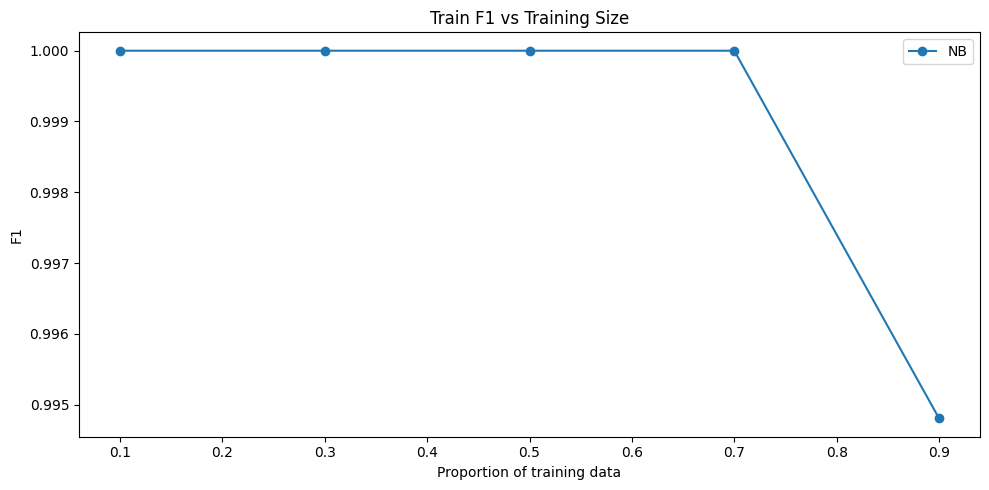

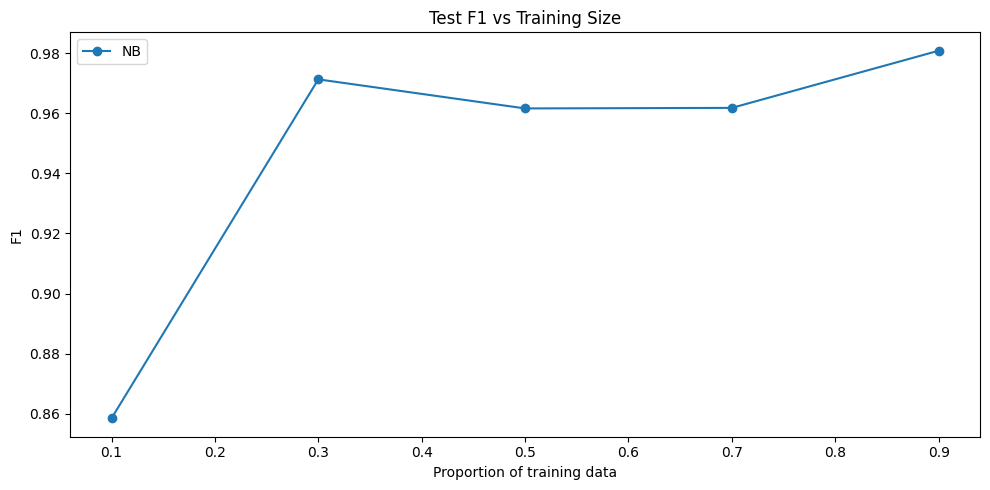

In [ ]:
# Task 3(c)
m_values  = [0.1, 0.3, 0.5, 0.7, 0.9]
num_train_samples = X_train.shape[0] # total number of training samples
train_f1, test_f1 = [], []

for m in m_values:
    n = int(m * num_train_samples) # number of samples to use for training
    nb_subset_model = MultinomialNB(alpha=best_alpha) # train NB model on subset of training data
    nb_subset_model.fit(X_train[:n], y_train.iloc[:n]) # fit model on first n samples of training data
    train_f1.append(f1_score(y_train.iloc[:n], nb_subset_model.predict(X_train[:n]), average='macro')) # compute F1 on training subset
    test_f1.append(f1_score(y_test, nb_subset_model.predict(X_test), average='macro')) # compute F1 on test set

plt.figure(figsize=(10, 5))
plt.plot(m_values, train_f1, marker='o', label='NB')
plt.xlabel('Proportion of training data')
plt.ylabel('F1')
plt.title('Train F1 vs Training Size')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(m_values, test_f1, marker='o', label='NB')
plt.xlabel('Proportion of training data')
plt.ylabel('F1')
plt.title('Test F1 vs Training Size')
plt.legend()
plt.tight_layout()
plt.show()

For task 3(c), I test the affect of training data size on the NB model performance, the first plot shows train F1 score and the second plot shows test F1 score.

In the train F1 score plot, I find that when m = 0.1, 0.3, 0.5, 0.7, F1 score is 1, when m = 0.9, F1 score decrease to about 0.995. Although the F1 score decreased, the performance is still good. This shows NB model fits the training data very well even we use subset of training data.

In the test F1 score plot, when m = 0.1, F1 score is about 0.86 it's a little bit lower than others. When m = 0.3, 0.5, 0.7, 0.9 F1 score is increase to about 0.97 or higher. It shows when we use more training data we can get the model becomes more stable.